# LDA-TBA (Latent Dirichlet Allocation-based Time Budget Allocation)

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime
import ast
import seaborn as sns
import math

## Configs

In [2]:
city = "london"  # {"london", "singapore"}
str_study_period = "20250210_20250223"
loc_embed_type = "lda"

if city == "london":
    proj_crs = "EPSG:27700"
elif city == "singapore":
    proj_crs = "EPSG:3414"

# Clustering config: almost all are default values suggested by BERTopic -- we do not tune them because it's not the focus of this work.
# These params are kept consistent across all models to ensure a fair comparison of the representation methods.
umap_config = {
    "n_neighbors": 30,  # Controls how UMAP balances local vs global structure (30-50 is good for 100k rows)
    "min_dist": 0.0,  # Set to 0.0 to pack points tightly together for better density clustering
    "n_components": 5,  # The dimensionality of the space to embed into. For visualization, 2 is common. For clustering, the default of 5 is a good starting point, but you can experiment with this.
    "metric": 'hellinger',   # Hellinger distance is a natural choice for comparing probability distributions, and it works natively in UMAP!
    "random_state": 101  # For reproducibility
}

## Helper functions

In [3]:
def get_data_dir_path(target_dir_str="mobility_data"):
    """
    Get data dir by seearching the current directory for the folder named 
    If there is no folder named {target_dir_str}, then search the parrent directory for it.
    Do this until a folder named {target_dir_str} is found or the root directory is reached
    """
    current_dir = os.getcwd()
    target_data_dir = None
    while True:
        if target_dir_str in os.listdir(current_dir):
            target_data_dir = os.path.join(current_dir, target_dir_str)
            break
        else:
            parent_dir = os.path.dirname(current_dir)
            if parent_dir == current_dir:  # Reached the root directory
                print(f"Error: Could not find a folder named '{target_dir_str}' in the current directory or any of its parent directories.")
                break
            current_dir = parent_dir
    return target_data_dir

## 1. Prepare Data

### 1.1. POI Data

In [6]:
if city == 'london':
    print("Loading London POI data...\n")
    gdf_poi = gpd.read_file(f'/home/xlwang/data/poi/london_bbox_202503/poi_6405256/poi_6405256.gpkg')
    print(f"Number of unique Group: {gdf_poi['groupname'].nunique()}")
    print(f"Number of unique Category: {gdf_poi['categoryname'].nunique()}")
    print(f"Number of unique Class: {gdf_poi['classname'].nunique()}")

else:
    pass

Loading London POI data...

Number of unique Group: 9
Number of unique Category: 52
Number of unique Class: 583


In [7]:
gdf_poi['classname'].isna().sum()

np.int64(0)

### 1.2. Significant Places

In [11]:
sigplaces_data_path = get_data_dir_path("sigplaces_and_home")
sigplaces_data_filename = f"{city}_{str_study_period}_sigplaces_with_home.csv.gz"
sigplaces_data_path = os.path.join(sigplaces_data_path, sigplaces_data_filename)
print(f"Loading sigplaces data from {sigplaces_data_path}...\n")
df_sigplaces = pd.read_csv(sigplaces_data_path)
df_sigplaces

Loading sigplaces data from /home/xlwang/code/2026/ACE/sigplaces_and_home/london_20250210_20250223_sigplaces_with_home.csv.gz...



,user_id,significant_place,nighttime_length,total_time_s,cluster_x,cluster_y,is_home
0,000088cc-b646-409b-a026-69cd9d47b838,0,43200,95333,530161.650419,159894.898575,True
1,000088cc-b646-409b-a026-69cd9d47b838,1,0,3170,527406.321829,177483.676174,NaN
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,0,6051,553352.580561,182964.732347,True
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,0,1195,553875.110693,182649.901302,NaN
4,000135bd-bf0b-4880-af99-1791ce98dddf,0,122407,335275,521030.394811,168403.307828,True
...,...,...,...,...,...,...,...
937808,ffff8ebb-33d5-4851-a36d-12de4548ea2e,7,0,3757,535298.958350,191977.129395,NaN
937809,ffff8ebb-33d5-4851-a36d-12de4548ea2e,8,0,405,534199.999362,191917.508375,NaN
937810,ffff8ebb-33d5-4851-a36d-12de4548ea2e,9,0,1463,532805.730369,196302.510275,NaN
937811,ffff8ebb-33d5-4851-a36d-12de4548ea2e,10,0,1763,536249.589648,185336.063915,NaN


## 2. Semantic Enrichment of Significant Places

In [13]:
gdf_sigplaces = gpd.GeoDataFrame(df_sigplaces, 
                                 geometry=gpd.points_from_xy(df_sigplaces['cluster_x'], 
                                                             df_sigplaces['cluster_y'], 
                                                             crs=proj_crs))

# Use the 150 metre buffer to get the POIs around the significant places
# If using 100m radius buffer, number of NaN rows will be too many.
gdf_sigplaces['geometry'] = gdf_sigplaces.geometry.buffer(150)

In [14]:
# Get the POIs around the significant places by spatial join
gdf_sigplaces_poi = gpd.sjoin(gdf_sigplaces, gdf_poi, how='left', predicate='contains')
# Drop the rows with missing POI information (i.e., no POI around the significant place)
print(f"Number of rows that have NaN in index_right (i.e., no POI around the significant place): {gdf_sigplaces_poi['index_right'].isna().sum():,}")
# gdf_sigplaces_poi = gdf_sigplaces_poi.dropna(subset=['index_right'])
print(f"We do not drop these rows; we might look into these significant places without POIs around them later.")

Number of rows that have NaN in index_right (i.e., no POI around the significant place): 11,934
We do not drop these rows; we might look into these significant places without POIs around them later.


In [15]:
# Separate sig places with and without POIs around them
gdf_sigplaces_poi_with_poi = gdf_sigplaces_poi[~gdf_sigplaces_poi['index_right'].isna()]
gdf_sigplaces_poi_without_poi = gdf_sigplaces_poi[gdf_sigplaces_poi['index_right'].isna()]
print(f"Num of sig places with pois around them: {len(gdf_sigplaces_poi_with_poi):,}")
print(f"Num of sig places without pois around them: {len(gdf_sigplaces_poi_without_poi):,}")

Num of sig places with pois around them: 38,203,337
Num of sig places without pois around them: 11,934


In [16]:
# Deal with the sig places without POIs first
gdf_sigplaces_poi_without_poi = gdf_sigplaces_poi_without_poi[['user_id', 'significant_place', 
                                                               'cluster_x', 'cluster_y', 'is_home']]
gdf_sigplaces_poi_without_poi['list_classname'] = np.nan
gdf_sigplaces_poi_without_poi

,user_id,significant_place,cluster_x,cluster_y,is_home,list_classname
15,00016f95-edc9-4642-a6e6-70ce63b66346,6,510010.628845,177605.463956,NaN,NaN
18,00016f95-edc9-4642-a6e6-70ce63b66346,9,507590.959707,174429.241756,NaN,NaN
54,0003d218-1f12-41f1-a070-4b1205aef565,8,546040.560549,191127.116675,NaN,NaN
94,0006d801-389e-4e3a-a4e5-4baca2077ff8,4,504172.513970,173416.846163,NaN,NaN
237,0012515f-a8b6-4004-a06e-1f379408288e,1,507726.233055,183242.787385,NaN,NaN
...,...,...,...,...,...,...
937629,fff4e4a1-0efb-4c74-af08-e600bea4f89f,4,552611.276672,164323.670616,NaN,NaN
937702,fff86e29-c11b-467d-a33c-46ca196367e1,2,540913.159988,193587.247386,NaN,NaN
937703,fff86e29-c11b-467d-a33c-46ca196367e1,3,540896.648829,193374.099133,NaN,NaN
937753,fffb92a5-26a3-4921-a501-0bea6b6b16de,8,521933.005107,157630.256117,NaN,NaN


In [17]:
# Get the list of POIs around each significant place
df_sigplaces_poi_list = gdf_sigplaces_poi_with_poi.groupby(['user_id', 'significant_place'], 
                                                  as_index=False).agg({'classname': list,
                                                                       'cluster_x': 'first',
                                                                       'cluster_y': 'first',
                                                                       'is_home': 'first'
                                                                       })

df_sigplaces_poi_list = df_sigplaces_poi_list.rename(columns={'classname': 'list_classname'})
df_sigplaces_poi_list  # columns: ['user_id', 'significant_place', 'list_classname', 'cluster_x', 'cluster_y']

,user_id,significant_place,list_classname,cluster_x,cluster_y,is_home
0,000088cc-b646-409b-a026-69cd9d47b838,0,"[Letter Boxes, Dental Surgeries, Nursing and R...",530161.650419,159894.898575,True
1,000088cc-b646-409b-a026-69cd9d47b838,1,"[Bridges, Ferries and Ferry Terminals, Histori...",527406.321829,177483.676174,None
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,"[Import and Export Services, First, Primary an...",553352.580561,182964.732347,True
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,"[Drinking Fountains and Water Points, Bus Stop...",553875.110693,182649.901302,None
4,000135bd-bf0b-4880-af99-1791ce98dddf,0,"[Cleaning Services, Building Contractors, Elec...",521030.394811,168403.307828,True
...,...,...,...,...,...,...
925874,ffff8ebb-33d5-4851-a36d-12de4548ea2e,7,"[Bus Stops, Bus Stops, Petrol and Fuel Station...",535298.958350,191977.129395,None
925875,ffff8ebb-33d5-4851-a36d-12de4548ea2e,8,"[Estate and Property Management, Places Of Wor...",534199.999362,191917.508375,None
925876,ffff8ebb-33d5-4851-a36d-12de4548ea2e,9,"[Building Repairs, Parking, Letter Boxes, Bus ...",532805.730369,196302.510275,None
925877,ffff8ebb-33d5-4851-a36d-12de4548ea2e,10,"[Playgrounds, Electrical Features, Estate and ...",536249.589648,185336.063915,None


In [ ]:
# Seems like saving those sigplaces without pois is not very useful, since they are not used for LDA anyway.
# # Concatenate the sig places with and without POIs back together
# df_sigplaces_poi_list = pd.concat([df_sigplaces_poi_list, gdf_sigplaces_poi_without_poi], ignore_index=True)

df_sigplaces_poi_list = df_sigplaces_poi_list.sort_values(by=['user_id', 'significant_place'])
df_sigplaces_poi_list

,user_id,significant_place,list_classname,cluster_x,cluster_y,is_home
0,000088cc-b646-409b-a026-69cd9d47b838,0,"[Letter Boxes, Dental Surgeries, Nursing and R...",530161.650419,159894.898575,True
1,000088cc-b646-409b-a026-69cd9d47b838,1,"[Bridges, Ferries and Ferry Terminals, Histori...",527406.321829,177483.676174,None
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,"[Import and Export Services, First, Primary an...",553352.580561,182964.732347,True
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,"[Drinking Fountains and Water Points, Bus Stop...",553875.110693,182649.901302,None
4,000135bd-bf0b-4880-af99-1791ce98dddf,0,"[Cleaning Services, Building Contractors, Elec...",521030.394811,168403.307828,True
...,...,...,...,...,...,...
925874,ffff8ebb-33d5-4851-a36d-12de4548ea2e,7,"[Bus Stops, Bus Stops, Petrol and Fuel Station...",535298.958350,191977.129395,None
925875,ffff8ebb-33d5-4851-a36d-12de4548ea2e,8,"[Estate and Property Management, Places Of Wor...",534199.999362,191917.508375,None
925876,ffff8ebb-33d5-4851-a36d-12de4548ea2e,9,"[Building Repairs, Parking, Letter Boxes, Bus ...",532805.730369,196302.510275,None
925877,ffff8ebb-33d5-4851-a36d-12de4548ea2e,10,"[Playgrounds, Electrical Features, Estate and ...",536249.589648,185336.063915,None


In [ ]:
# We can choose not to save sigplacecs with poi list because the file will be rather large.
# Instead, we save the final topic distribution of each significant place after LDA.

# # Save sigplaces_poi_list. Note this file could be rather large.
# df_sigplaces_poi_list.to_csv(f"{city}_{str_study_period}_sigplaces_poi_list.csv.gz", index=False)

## 3. Activity-travel Profile Representation

In [10]:
import time
import ast
import gensim
from gensim.corpora import Dictionary
from gensim.models import TfidfModel, LdaModel, LdaMulticore

### 3.1. Prepare Data for LDA

In [ ]:
# # Read sigplaces_poi_list from local folder
# df_sigplaces_poi_list = pd.read_csv(f'{city}_{str_study_period}_sigplaces_poi_list.csv.gz', compression='gzip')

# # Remove NaN rows in df_sigplaces_poi_list (i.e., significant places without POIs around them)
# df_sigplaces_poi_list = df_sigplaces_poi_list.dropna(subset=['list_classname']).reset_index(drop=True)
# df_sigplaces_poi_list['list_classname'] = df_sigplaces_poi_list['list_classname'].apply(ast.literal_eval)

In [ ]:
df_sigplaces_poi_list

,user_id,significant_place,list_classname,cluster_x,cluster_y,is_home
0,000088cc-b646-409b-a026-69cd9d47b838,0,"[Letter Boxes, Dental Surgeries, Nursing and R...",530161.650419,159894.898575,True
1,000088cc-b646-409b-a026-69cd9d47b838,1,"[Bridges, Ferries and Ferry Terminals, Histori...",527406.321829,177483.676174,None
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,"[Import and Export Services, First, Primary an...",553352.580561,182964.732347,True
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,"[Drinking Fountains and Water Points, Bus Stop...",553875.110693,182649.901302,None
4,000135bd-bf0b-4880-af99-1791ce98dddf,0,"[Cleaning Services, Building Contractors, Elec...",521030.394811,168403.307828,True
...,...,...,...,...,...,...
925874,ffff8ebb-33d5-4851-a36d-12de4548ea2e,7,"[Bus Stops, Bus Stops, Petrol and Fuel Station...",535298.958350,191977.129395,None
925875,ffff8ebb-33d5-4851-a36d-12de4548ea2e,8,"[Estate and Property Management, Places Of Wor...",534199.999362,191917.508375,None
925876,ffff8ebb-33d5-4851-a36d-12de4548ea2e,9,"[Building Repairs, Parking, Letter Boxes, Bus ...",532805.730369,196302.510275,None
925877,ffff8ebb-33d5-4851-a36d-12de4548ea2e,10,"[Playgrounds, Electrical Features, Estate and ...",536249.589648,185336.063915,None


In [21]:
# Inspect one classname list
df_sigplaces_poi_list.loc[0, 'list_classname'][0]

'Letter Boxes'

In [22]:
texts = df_sigplaces_poi_list['list_classname'].values.tolist()
print(texts[0])

# Prepare your data (assuming 'texts' is a list of tokenized documents)
dictionary = Dictionary(texts)

corpus = [dictionary.doc2bow(text) for text in texts]

print(f"The length of the corpus is: {len(corpus):,}")
print(f"Dictionary size: {len(dictionary)}")
print(f"Token IDs: {dictionary.token2id}")
print(f"First document in corpus: {corpus[0]}")

['Letter Boxes', 'Dental Surgeries', 'Nursing and Residential Care Homes', 'Places Of Worship', 'Bus Stops', 'Nursing and Residential Care Homes', 'Nursing and Residential Care Homes', 'Telecommunications Features', 'Bus Stops']
The length of the corpus is: 925,879
Dictionary size: 582
Token IDs: {'Bus Stops': 0, 'Dental Surgeries': 1, 'Letter Boxes': 2, 'Nursing and Residential Care Homes': 3, 'Places Of Worship': 4, 'Telecommunications Features': 5, 'Bridges': 6, 'Ferries and Ferry Terminals': 7, 'Footbridges': 8, 'Historic and Ceremonial Structures': 9, 'Unspecified and Other Attractions': 10, 'Electrical Features': 11, 'Electrical and Electronic Engineers': 12, 'First, Primary and Infant Schools': 13, 'Import and Export Services': 14, 'Cleaning Services': 15, 'Drinking Fountains and Water Points': 16, 'Fast Food and Takeaway Outlets': 17, 'Hair and Beauty Services': 18, 'Vehicle Parts and Accessories': 19, 'Building Contractors': 20, 'Accountants and Auditors': 21, 'Architectural a

### 3.2. Find the Optimal Number of Topics by Perplexity Score

In [ ]:
def compute_perplexity_values(dictionary, corpus, limit, start=2, step=3):
    perplexity_values = []
    model_list = []
    
    for num_topics in range(start, limit, step):
        # Train the model
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10)
        model_list.append(model)
        
        # Calculate Perplexity (log_perplexity returns the log of the bound)
        # We convert it back to the standard perplexity scale
        perplexity = model.log_perplexity(corpus)
        perplexity_values.append(2**(-perplexity))
        
        print(f"Num Topics: {num_topics}, Perplexity: {2**(-perplexity):.2f}")

    return model_list, perplexity_values


def compute_fast_perplexity(dictionary, corpus, limit, start=2, step=4, num_workers=8):
    perplexity_values = {}
    print(f"Using {num_workers} workers for parallel processing...")
    
    for num_topics in range(start, limit, step):
        # Using LdaMulticore for parallel processing
        # Lowering 'passes' for the tuning phase to save time
        model = LdaMulticore(
            corpus=corpus, 
            id2word=dictionary, 
            num_topics=num_topics, 
            workers=num_workers,
            passes=2,          # Reduced for speed during tuning
            iterations=50,     # Lower iterations for faster convergence
            random_state=101
        )
        
        # Calculate log_perplexity and convert
        log_perplexity = model.log_perplexity(corpus)
        perplexity = 2**(-log_perplexity)
        perplexity_values[num_topics] = perplexity
        
        print(f"Testing K={num_topics} | Perplexity: {perplexity:.2f}")

    return perplexity_values

In [36]:
# Run another evaluation
st = time.time()
step = 2
start, limit = 2, 50+step*1

perp_scores = compute_fast_perplexity(dictionary, corpus, limit, start, step, num_workers=64)

et = time.time()
print(f"Time taken: {et - st:.2f} seconds")

Using 64 workers for parallel processing...
Testing K=2 | Perplexity: 23.67
Testing K=4 | Perplexity: 22.29
Testing K=6 | Perplexity: 21.45
Testing K=8 | Perplexity: 21.20
Testing K=10 | Perplexity: 20.67
Testing K=12 | Perplexity: 20.54
Testing K=14 | Perplexity: 20.43
Testing K=16 | Perplexity: 20.36
Testing K=18 | Perplexity: 20.14
Testing K=20 | Perplexity: 20.06
Testing K=22 | Perplexity: 20.09
Testing K=24 | Perplexity: 20.07
Testing K=26 | Perplexity: 20.03
Testing K=28 | Perplexity: 19.98
Testing K=30 | Perplexity: 19.91
Testing K=32 | Perplexity: 20.00
Testing K=34 | Perplexity: 20.00
Testing K=36 | Perplexity: 19.93
Testing K=38 | Perplexity: 19.88
Testing K=40 | Perplexity: 19.78
Testing K=42 | Perplexity: 19.81
Testing K=44 | Perplexity: 19.75
Testing K=46 | Perplexity: 19.78
Testing K=48 | Perplexity: 19.79
Testing K=50 | Perplexity: 19.80
Time taken: 4351.23 seconds


In [23]:
# df_perp_scores = pd.DataFrame(list(perp_scores.items()), columns=['num_topics', 'perplexity'])
# df_perp_scores.to_csv("df_perp_scores.csv", index=False)

# Read the perplexity scores from the csv file that was computed and saved before
df_perp_scores = pd.read_csv("df_perp_scores.csv")
df_perp_scores

,num_topics,perplexity
0,2,28.2556
1,4,26.4785
2,6,26.2861
3,8,26.1242
4,10,26.0745
5,12,25.8485
6,14,25.7540
7,16,25.7798
8,18,25.7148
9,20,25.6630


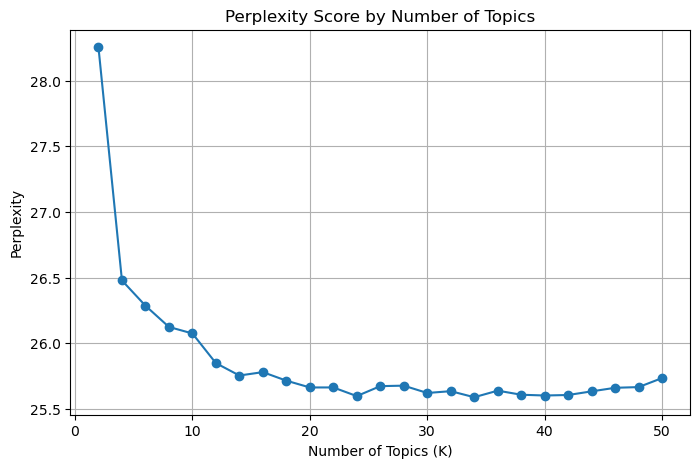

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(df_perp_scores['num_topics'], df_perp_scores['perplexity'], marker='o', linestyle='-')
plt.title("Perplexity Score by Number of Topics")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Perplexity")
plt.grid(True)
plt.show()

Observing the perplexity scores curve, we can choose the optimal number of topics based on the Elbow method.

In [13]:
k_optimal = 14
print(f"The optimal number of topics based on perplexity is: {k_optimal}")

The optimal number of topics based on perplexity is: 14


### 3.3. Fitting the Final LDA Model with the Chosen Number of Topics

In [31]:
# 1. Final Train: could increase passes and iterations for better convergence
final_lda_model = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=k_optimal, 
    workers=32,
    passes=2,
    iterations=50,     # Default is 50, and used in many papers.
    random_state=101,   # For reproducibility
    # alpha='symmetric'   # Or 'auto' if you want the model to learn asymmetric priors
)

# Save your masterpiece
save_pretrained_dir = "pretrained_lda"
if not os.path.exists(save_pretrained_dir):
    os.makedirs(save_pretrained_dir)
final_lda_model.save(f"{save_pretrained_dir}/final_lda_k{k_optimal}_{city}.model")

In [14]:
# Load saved lda model
final_lda_model = LdaModel.load(f"pretrained_lda/final_lda_k{k_optimal}_{city}.model")

In [15]:
from pprint import pprint
# Print the 10 most significant words for each of the k_optimal topics
pprint(final_lda_model.print_topics(num_topics=k_optimal, num_words=10))

[(0,
  '0.090*"Bus Stops" + 0.064*"Hair and Beauty Services" + 0.054*"Convenience '
  'Stores and Independent Supermarkets" + 0.049*"Electrical Features" + '
  '0.046*"Fast Food and Takeaway Outlets" + 0.040*"Restaurants" + 0.029*"Cash '
  'Machines" + 0.027*"Paypoint Locations" + 0.025*"Cafes, Snack Bars and Tea '
  'Rooms" + 0.023*"Letter Boxes"'),
 (1,
  '0.053*"Bus Stops" + 0.046*"Cash Machines" + 0.039*"Clothing" + '
  '0.033*"Restaurants" + 0.027*"Fast Food and Takeaway Outlets" + '
  '0.026*"Accountants and Auditors" + 0.023*"Computer Systems Services" + '
  '0.022*"Jewellery and Fashion Accessories" + 0.019*"Employment Agencies" + '
  '0.017*"Travel Agencies"'),
 (2,
  '0.090*"Electrical Features" + 0.059*"Bus Stops" + 0.058*"Vehicle Repair, '
  'Testing and Servicing" + 0.046*"Diy and Home Improvement" + 0.029*"Cash '
  'Machines" + 0.028*"Convenience Stores and Independent Supermarkets" + '
  '0.025*"Vehicle Cleaning Services" + 0.024*"Petrol and Fuel Stations" + '
  '0.022*"

#### 3.3.1 Manually Label the Topics

In [ ]:
list_semantics = ['Residential and Housing',
    'Commercial and Business',
    'Industrial and Manufacturing',
    'Education and Schools',
    'Grocery and Convenience',
    'Medical and Healthcare',
    'Eating and Drinking',
    'Shopping and Retail',
    'Entertainment, Arts, and Culture',
    'Parks and Greenspace',
    'Civic, Governmental, and Public Facilities',
    'Transport and Transit']

# Manually assign semantics to each topic based on the top words
topic_semantics_mapping = {
    0: 'Grocery and Convenience',
    1: 'Eating and Drinking',
    2: 'Medical and Healthcare',
    3: 'Shopping and Retail',
    4: 'Education and Schools',
    5: 'Shopping and Retail',
    6: 'Shopping and Retail',
    7: 'Commercial and Business',
    8: 'Transport and Transit',
    9: 'Commercial and Business',
    10: 'Commercial and Business',
    11: 'Shopping and Retail',
    12: 'Residential and Housing',
    13: 'Residential and Housing',
    14: 'Transport and Transit',
    15: 'Parks and Greenspace',
    16: 'Industrial and Manufacturing',
    17: 'Civic, Governmental, and Public Facilities',
    18: 'Commercial and Business',
    19: 'Entertainment, Arts, and Culture'
}

In [35]:
def get_full_topic_distribution(model, corpus):
    all_document_distributions = []

    for bow in corpus:
        # 1. Force Gensim to return ALL topics by setting minimum_probability=0.0
        doc_topics = model.get_document_topics(bow, minimum_probability=0.0)
        
        # doc_topics is a list of tuples: [(0, 0.05), (1, 0.12), ... (17, 0.01)]
        # 2. Extract just the probability values
        # Because we set minimum_probability=0, they are guaranteed to be sorted from Topic 0 to k-1
        topic_probs = [float(prob) for topic_id, prob in doc_topics]
        
        all_document_distributions.append(topic_probs)

    # Create a DataFrame with a single column containing the lists
    # df_distribution = pd.DataFrame({'Topic_Distribution': all_document_distributions})
    
    return all_document_distributions

# Run the function on your corpus
# df_full_topics = get_full_topic_distribution(final_lda_model, corpus, num_topics=18)
list_full_topic_distributions = get_full_topic_distribution(final_lda_model, corpus)


# Optional: Add your original text back in for context
# df_full_topics['Original_Text'] = texts 

In [36]:
len(list_full_topic_distributions)
print(list_full_topic_distributions[0])

[0.007142967544496059, 0.007142944727092981, 0.007142955902963877, 0.007142942398786545, 0.007142947521060705, 0.007142947055399418, 0.5340036749839783, 0.007142949849367142, 0.007142934016883373, 0.007142952643334866, 0.007142943330109119, 0.007142940070480108, 0.00714295357465744, 0.38028091192245483]


In [37]:
list_full_topic_distributions = [
    [float(x) for x in doc_probs]
    for doc_probs in list_full_topic_distributions
]
list_full_topic_distributions

[[0.007142967544496059,
  0.007142944727092981,
  0.007142955902963877,
  0.007142942398786545,
  0.007142947521060705,
  0.007142947055399418,
  0.5340036749839783,
  0.007142949849367142,
  0.007142934016883373,
  0.007142952643334866,
  0.007142943330109119,
  0.007142940070480108,
  0.00714295357465744,
  0.38028091192245483],
 [0.008928699418902397,
  0.008928685449063778,
  0.008928698487579823,
  0.008928694762289524,
  0.008928695693612099,
  0.008928689174354076,
  0.008928743191063404,
  0.008928685449063778,
  0.008928688243031502,
  0.008928686380386353,
  0.0089286919683218,
  0.0089286919683218,
  0.008928744122385979,
  0.8839269280433655],
 [0.01190575584769249,
  0.01190576609224081,
  0.011905997060239315,
  0.011905760504305363,
  0.0119057297706604,
  0.01190574187785387,
  0.8452249765396118,
  0.011905726045370102,
  0.011905764229595661,
  0.0119057297706604,
  0.011905736289918423,
  0.011905721388757229,
  0.011905726976692677,
  0.011905808933079243],
 [0.8968

In [39]:
sum(list_full_topic_distributions[34])  # should be very close to 1.0.

1.000000324100256

In [40]:
df_sigplaces_poi_list['topic_dist'] = list_full_topic_distributions
df_sigplaces_topic_dist = df_sigplaces_poi_list[['user_id', 'significant_place', 'topic_dist']]
df_sigplaces_topic_dist

,user_id,significant_place,topic_dist
0,000088cc-b646-409b-a026-69cd9d47b838,0,"[0.007142967544496059, 0.007142944727092981, 0..."
1,000088cc-b646-409b-a026-69cd9d47b838,1,"[0.008928699418902397, 0.008928685449063778, 0..."
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,"[0.01190575584769249, 0.01190576609224081, 0.0..."
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,"[0.8968216776847839, 0.007936745882034302, 0.0..."
4,000135bd-bf0b-4880-af99-1791ce98dddf,0,"[0.007936659269034863, 0.007936626672744751, 0..."
...,...,...,...
925874,ffff8ebb-33d5-4851-a36d-12de4548ea2e,7,"[0.003968313802033663, 0.003968313802033663, 0..."
925875,ffff8ebb-33d5-4851-a36d-12de4548ea2e,8,"[0.010204375721514225, 0.010204402729868889, 0..."
925876,ffff8ebb-33d5-4851-a36d-12de4548ea2e,9,"[0.0017858202336356044, 0.0017858208157122135,..."
925877,ffff8ebb-33d5-4851-a36d-12de4548ea2e,10,"[0.0034014126285910606, 0.0034014051780104637,..."


In [41]:
df_sigplaces_topic_dist.to_csv(f"{city}_{str_study_period}_sigplaces_topic_dist.csv.gz", index=False)

### 3.4 Derive User Activity Profile Representation

In [8]:
# Read the saved stays and sigplaces data, and then merge them
mobility_data_dir = get_data_dir_path("mobility_data")
mobility_data_file = f"{city}_{str_study_period}_stays_bbox_min2staysperday_with_sigplaces.csv.gz"
mobility_data_path = os.path.join(mobility_data_dir, mobility_data_file)
print(f"Loading mobility data from {mobility_data_path}...\n")

df_stays = pd.read_csv(mobility_data_path)
df_stays['start_time'] = pd.to_datetime(df_stays['start_time'])
df_stays['end_time'] = pd.to_datetime(df_stays['end_time'])
df_stays['duration_s'] = (df_stays['end_time'] - df_stays['start_time']).dt.total_seconds()
df_stays

Loading mobility data from /home/xlwang/code/2026/ACE/mobility_data/london_20250210_20250223_stays_bbox_min2staysperday_with_sigplaces.csv.gz...



,user_id,start_time,end_time,longitude,latitude,significant_place,duration_s
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,33288.0
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 13:52:23,2025-02-18 14:45:13,-0.166586,51.481968,1,3170.0
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 19:43:05,2025-02-18 22:53:39,-0.133383,51.323275,0,11434.0
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 01:43:03,2025-02-19 10:49:59,-0.133407,51.323269,0,32816.0
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 17:46:28,2025-02-19 22:43:03,-0.133356,51.323277,0,17795.0
...,...,...,...,...,...,...,...
3498974,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 18:49:56,2025-02-22 21:52:59,-0.032223,51.672417,2,10983.0
3498975,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 21:58:39,2025-02-22 22:03:14,-0.030292,51.656460,11,275.0
3498976,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 22:20:47,2025-02-22 23:38:46,-0.045203,51.624544,0,4679.0
3498977,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 00:01:13,2025-02-23 11:23:11,-0.045215,51.624603,0,40918.0


In [16]:
# Read the saved sigplaces topic distribution
df_sigplaces_topic_dist = pd.read_csv(f"{city}_{str_study_period}_sigplaces_topic_dist.csv.gz")
# Convert the list in the topic_dist column from string back to list
df_sigplaces_topic_dist['topic_dist'] = df_sigplaces_topic_dist['topic_dist'].apply(ast.literal_eval)


df_stay_with_sigplace = pd.merge(df_stays, df_sigplaces_topic_dist, on=['user_id', 'significant_place'], how='left')

num_stays_with_nan_topic_dist = df_stay_with_sigplace['topic_dist'].isna().sum()
print(f"Number and percentage of stays with NaN topic distribution: {num_stays_with_nan_topic_dist:,}, {num_stays_with_nan_topic_dist / len(df_stay_with_sigplace) * 100:.2f}%")
# Remove the stays with NaN topic dist (i.e., those significant places without POIs around them)
df_stay_with_sigplace = df_stay_with_sigplace.dropna(subset=['topic_dist']).reset_index(drop=True)
print(f"After dropping NaN topic distribution, number of stays left: {len(df_stay_with_sigplace):,}")
df_stay_with_sigplace

Number and percentage of stays with NaN topic distribution: 39,344, 1.12%
After dropping NaN topic distribution, number of stays left: 3,459,635


,user_id,start_time,end_time,longitude,latitude,significant_place,duration_s,topic_dist
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,33288.0,"[0.007142967544496059, 0.007142944727092981, 0..."
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 13:52:23,2025-02-18 14:45:13,-0.166586,51.481968,1,3170.0,"[0.008928699418902397, 0.008928685449063778, 0..."
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 19:43:05,2025-02-18 22:53:39,-0.133383,51.323275,0,11434.0,"[0.007142967544496059, 0.007142944727092981, 0..."
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 01:43:03,2025-02-19 10:49:59,-0.133407,51.323269,0,32816.0,"[0.007142967544496059, 0.007142944727092981, 0..."
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 17:46:28,2025-02-19 22:43:03,-0.133356,51.323277,0,17795.0,"[0.007142967544496059, 0.007142944727092981, 0..."
...,...,...,...,...,...,...,...,...
3459630,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 18:49:56,2025-02-22 21:52:59,-0.032223,51.672417,2,10983.0,"[0.20326261222362518, 0.24118554592132568, 0.0..."
3459631,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 21:58:39,2025-02-22 22:03:14,-0.030292,51.656460,11,275.0,"[0.003246865700930357, 0.0032468566205352545, ..."
3459632,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 22:20:47,2025-02-22 23:38:46,-0.045203,51.624544,0,4679.0,"[0.014286519959568977, 0.014286505058407784, 0..."
3459633,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 00:01:13,2025-02-23 11:23:11,-0.045215,51.624603,0,40918.0,"[0.014286519959568977, 0.014286505058407784, 0..."


In [17]:
# Calculate time budget allocation for each user
df_user_sigplace_duration = df_stay_with_sigplace.groupby(['user_id', 'significant_place'], as_index=False).agg({'duration_s': 'sum'})

# Calculate the proportion of time spent at each significant place for each user
df_user_total_duration = df_user_sigplace_duration.groupby('user_id', as_index=False).agg({'duration_s': 'sum'}).rename(columns={'duration_s': 'total_duration_s'})
df_user_sigplace_duration = df_user_sigplace_duration.merge(df_user_total_duration, on='user_id', how='left')
df_user_sigplace_duration['time_proportion'] = df_user_sigplace_duration['duration_s'] / df_user_sigplace_duration['total_duration_s']

df_user_sigplace_duration

,user_id,significant_place,duration_s,total_duration_s,time_proportion
0,000088cc-b646-409b-a026-69cd9d47b838,0,95333.0,98503.0,0.967818
1,000088cc-b646-409b-a026-69cd9d47b838,1,3170.0,98503.0,0.032182
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,6051.0,7246.0,0.835081
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,1195.0,7246.0,0.164919
4,000135bd-bf0b-4880-af99-1791ce98dddf,0,335275.0,387851.0,0.864443
...,...,...,...,...,...
925874,ffff8ebb-33d5-4851-a36d-12de4548ea2e,7,3757.0,759153.0,0.004949
925875,ffff8ebb-33d5-4851-a36d-12de4548ea2e,8,405.0,759153.0,0.000533
925876,ffff8ebb-33d5-4851-a36d-12de4548ea2e,9,1463.0,759153.0,0.001927
925877,ffff8ebb-33d5-4851-a36d-12de4548ea2e,10,1763.0,759153.0,0.002322


In [18]:
# Merge the topic distribution information with the time allocation information
df_user_sigplace_duration = df_user_sigplace_duration.merge(df_sigplaces_topic_dist, on=['user_id', 'significant_place'], how='left')


# Now we weight the topic distribution by the time proportion to get the activity profile embedding for each user
def weighted_topic_distribution(row):
    topic_dist = row['topic_dist']
    time_prop = row['time_proportion']
    weighted_dist = [prob * time_prop for prob in topic_dist]
    return weighted_dist

df_user_sigplace_duration['weighted_topic_dist'] = df_user_sigplace_duration.apply(weighted_topic_distribution, axis=1)


def sum_weighted_distributions(group):
    list_dist = group['weighted_topic_dist'].tolist()
    summed_dist = [sum(x) for x in zip(*list_dist)]
    return pd.Series({'activity_profile_embedding': summed_dist})

df_user_activity_profile = df_user_sigplace_duration.groupby('user_id').apply(sum_weighted_distributions).reset_index()
df_user_activity_profile

,user_id,activity_profile_embedding
0,000088cc-b646-409b-a026-69cd9d47b838,"[0.007200435540819706, 0.007200413008146831, 0..."
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,"[0.15784482934966934, 0.011251200931987324, 0...."
2,000135bd-bf0b-4880-af99-1791ce98dddf,"[0.05047496908718652, 0.007098476217492361, 0...."
3,00016f95-edc9-4642-a6e6-70ce63b66346,"[0.017745289312209332, 0.014127804655025446, 0..."
4,0001dfff-15bc-404b-a5f2-a1ec0b458766,"[0.01511074482255483, 0.012252575464614354, 0...."
...,...,...
112020,fffeb333-944f-4663-aea6-f310fe721d03,"[0.011904851533472538, 0.011904822662472725, 0..."
112021,ffff1696-ce5a-499c-a567-1a9f612ca0c2,"[0.012858757381578661, 0.010258485981923169, 0..."
112022,ffff1d0a-e065-451c-ab38-61d881dae01f,"[0.005427960003139604, 0.005427920999463329, 0..."
112023,ffff2a7d-c1e9-4364-a074-59fc733599f6,"[0.035714466124773026, 0.03571435436606407, 0...."


In [46]:
# Sanity check: check if the sum of the activity profile embedding for each user is 1 (or close to 1 due to floating point precision)
df_user_activity_profile['embedding_sum'] = df_user_activity_profile['activity_profile_embedding'].apply(lambda x: sum(x))
df_user_activity_profile['embedding_sum'].describe()

count    1.120250e+05
mean     1.000000e+00
std      1.124372e-07
min      9.999995e-01
25%      9.999999e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.000001e+00
Name: embedding_sum, dtype: float64

In [47]:
# After the sanity check, we can drop the embedding_sum column
df_user_activity_profile.drop(columns=['embedding_sum'], inplace=True)

In [50]:
df_user_activity_profile

,user_id,activity_profile_embedding
0,000088cc-b646-409b-a026-69cd9d47b838,"[0.007200435540819706, 0.007200413008146831, 0..."
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,"[0.15784482934966934, 0.011251200931987324, 0...."
2,000135bd-bf0b-4880-af99-1791ce98dddf,"[0.05047496908718652, 0.007098476217492361, 0...."
3,00016f95-edc9-4642-a6e6-70ce63b66346,"[0.017745289312209332, 0.014127804655025446, 0..."
4,0001dfff-15bc-404b-a5f2-a1ec0b458766,"[0.01511074482255483, 0.012252575464614354, 0...."
...,...,...
112020,fffeb333-944f-4663-aea6-f310fe721d03,"[0.011904851533472538, 0.011904822662472725, 0..."
112021,ffff1696-ce5a-499c-a567-1a9f612ca0c2,"[0.012858757381578661, 0.010258485981923169, 0..."
112022,ffff1d0a-e065-451c-ab38-61d881dae01f,"[0.005427960003139604, 0.005427920999463329, 0..."
112023,ffff2a7d-c1e9-4364-a074-59fc733599f6,"[0.035714466124773026, 0.03571435436606407, 0...."


## 4. Clustering

The method of JSD + Hierarchical Clustering proposed in the original paper is not feasible. Because calculating pairwise Jensen-Shannon distances takes over 98 minutes and could not finish.

Therefore, we adopt the "UMAP dimensionality reduction + HDBSCAN" method. 

In [19]:
import os
import gc
import pickle

import numpy as np
import pandas as pd
import umap
from sklearn.cluster import HDBSCAN
from hdbscan.validity import validity_index

In [20]:
# Prepare data
ape_matrix = np.array(df_user_activity_profile['activity_profile_embedding'].tolist())
print(f"The shape of the activity profile embedding matrix is (num_users, num_topics): {ape_matrix.shape}")

The shape of the activity profile embedding matrix is (num_users, num_topics): (112025, 14)


In [21]:
umap_config = {
    "n_neighbors": 30,  # Controls how UMAP balances local vs global structure (30-50 is good for 100k rows)
    "min_dist": 0.0,  # Set to 0.0 to pack points tightly together for better density clustering
    "n_components": 5,  # The dimensionality of the space to embed into. For visualization, 2 is common. For clustering, the default of 5 is a good starting point, but you can experiment with this.
    "metric": 'hellinger',   # Hellinger distance is a natural choice for comparing probability distributions, and it works natively in UMAP!
    "random_state": 101  # For reproducibility
}

In [22]:
# Convert the list of 24-dim probability distributions into a 2D NumPy array
# for later visualisation and anlysis

print("Running UMAP Dimensionality Reduction, reducing to 2D first...")
# 2. Configure UMAP
# We use metric='hellinger' natively! UMAP will handle the math for you.
# Hellinger distance is a natural choice for comparing probability distributions, 
# and it will help UMAP to preserve the meaningful distances between users based on their activity profiles.

reducer = umap.UMAP(
    n_neighbors=umap_config['n_neighbors'],       # Controls how UMAP balances local vs global structure (30-50 is good for 48k rows)
    min_dist=umap_config['min_dist'],         # Set to 0.0 to pack points tightly together for better density clustering
    n_components=2,       # Explicitly set to 2 to get the 2D embeddings for visualization
    metric='hellinger',   # Natively respects probability distributions!
    random_state=umap_config['random_state']       # For reproducibility
)

# Fit and transform the data
embedding_2d = reducer.fit_transform(ape_matrix)
print("UMAP complete. Shape of new embeddings:", embedding_2d.shape)

# Takes 48 seconds to run (on timecore).

Running UMAP Dimensionality Reduction, reducing to 2D first...


/home/xlwang/miniforge3/envs/py312cu128/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/xlwang/miniforge3/envs/py312cu128/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: invalid value encountered in correct_alternative_hellinger
  return super().__call__(*args, **kws)


UMAP complete. Shape of new embeddings: (112025, 2)


In [23]:
df_user_activity_profile['umap_x'] = embedding_2d[:, 0]
df_user_activity_profile['umap_y'] = embedding_2d[:, 1]
df_user_activity_profile

,user_id,activity_profile_embedding,umap_x,umap_y
0,000088cc-b646-409b-a026-69cd9d47b838,"[0.007200435540819706, 0.007200413008146831, 0...",4.474168,-1.923559
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,"[0.15784482934966934, 0.011251200931987324, 0....",5.084412,4.951690
2,000135bd-bf0b-4880-af99-1791ce98dddf,"[0.05047496908718652, 0.007098476217492361, 0....",1.633864,2.978761
3,00016f95-edc9-4642-a6e6-70ce63b66346,"[0.017745289312209332, 0.014127804655025446, 0...",11.407210,6.282671
4,0001dfff-15bc-404b-a5f2-a1ec0b458766,"[0.01511074482255483, 0.012252575464614354, 0....",11.709895,6.492467
...,...,...,...,...
112020,fffeb333-944f-4663-aea6-f310fe721d03,"[0.011904851533472538, 0.011904822662472725, 0...",15.428790,6.169834
112021,ffff1696-ce5a-499c-a567-1a9f612ca0c2,"[0.012858757381578661, 0.010258485981923169, 0...",8.383412,1.842725
112022,ffff1d0a-e065-451c-ab38-61d881dae01f,"[0.005427960003139604, 0.005427920999463329, 0...",-6.155204,-3.669520
112023,ffff2a7d-c1e9-4364-a074-59fc733599f6,"[0.035714466124773026, 0.03571435436606407, 0....",-0.082984,17.802507


In [24]:
# Reduce to 5D for later clustering
reducer = umap.UMAP(
    n_neighbors=umap_config['n_neighbors'],       
    min_dist=umap_config['min_dist'],         
    n_components=umap_config['n_components'],
    metric=umap_config['metric'],
    random_state=umap_config['random_state']
)
embedding = reducer.fit_transform(ape_matrix)

/home/xlwang/miniforge3/envs/py312cu128/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/xlwang/miniforge3/envs/py312cu128/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: invalid value encountered in correct_alternative_hellinger
  return super().__call__(*args, **kws)


In [25]:
embedding

array([[ 6.8825374 ,  1.9012764 ,  5.0791664 ,  2.9958923 ,  3.437198  ],
       [ 6.365954  ,  1.4376178 ,  5.0609746 ,  8.168249  ,  3.425619  ],
       [ 8.570417  ,  3.2451916 ,  5.2121415 ,  5.490552  ,  2.0316029 ],
       ...,
       [10.914186  ,  2.241527  ,  0.8043401 ,  9.090344  , -2.174953  ],
       [ 7.3167644 ,  6.8506846 , 10.12764   , 15.366082  ,  3.8318732 ],
       [ 9.747592  ,  2.4500046 ,  2.7194023 ,  8.036425  , -0.15494311]],
      shape=(112025, 5), dtype=float32)

In [58]:
# Save and compress
np.savez_compressed(f'{city}_{loc_embed_type}_embedding_{umap_config["n_components"]}d.npz', my_embedding=embedding)

In [ ]:
# # To load:
# loaded = np.load(f'{city}_{loc_embed_type}_embedding_{umap_config["n_components"]}d.npz')
# embedding = loaded['my_embedding']
# embedding

array([[ 7.0822296 ,  3.4298723 ,  7.6577306 ,  2.2206948 ,  4.1556416 ],
       [ 5.7661743 ,  4.0540776 ,  7.011501  ,  3.6701753 ,  4.553297  ],
       [ 0.689035  ,  7.094334  ,  3.6882777 ,  6.31777   ,  4.3842177 ],
       ...,
       [-1.1282067 ,  6.6652637 ,  6.1887426 ,  3.5493119 ,  3.3859758 ],
       [ 8.164014  ,  0.07042149, 10.320784  ,  1.9192028 ,  3.944728  ],
       [ 1.9947723 ,  4.9259276 ,  6.043358  ,  3.3334134 ,  3.8111818 ]],
      shape=(112096, 5), dtype=float32)

In [27]:
# HDBSCAN parameter tuning config
clustering_output_dir = f'{city}_{str_study_period}_{loc_embed_type}_clustering'
os.makedirs(clustering_output_dir, exist_ok=True)

hdbscan_params_combinations = [
    {'min_cluster_size': 1000, 'min_samples': 20},
    {'min_cluster_size': 1000, 'min_samples': 30},
    {'min_cluster_size': 1000, 'min_samples': 50},
    {'min_cluster_size': 1000, 'min_samples': 100},
    {'min_cluster_size': 1000, 'min_samples': 200},
    {'min_cluster_size': 1000, 'min_samples': 300},
    {'min_cluster_size': 1000, 'min_samples': 500},
    {'min_cluster_size': 1000, 'min_samples': 1000},
    {'min_cluster_size': 2000, 'min_samples': 30},
    {'min_cluster_size': 2000, 'min_samples': 50},
    {'min_cluster_size': 2000, 'min_samples': 100},
    {'min_cluster_size': 2000, 'min_samples': 200},
    {'min_cluster_size': 2000, 'min_samples': 500},
    {'min_cluster_size': 2000, 'min_samples': 1000},
    {'min_cluster_size': 2000, 'min_samples': 2000},
]

# DBCV is higher when clusters are denser and better separated.
dbcv_metric = 'euclidean'
# Exact full-data DBCV can be slow. Use None for exact, or e.g. 30000 for a sampled score.
dbcv_sample_size = 30000
dbcv_random_state = umap_config['random_state']


def _make_dbcv_score_subset(labels, sample_size=dbcv_sample_size, random_state=dbcv_random_state):
    if sample_size is None or sample_size >= len(labels):
        return np.arange(len(labels))
    rng = np.random.default_rng(random_state)
    return np.sort(rng.choice(len(labels), size=sample_size, replace=False))


def evaluate_hdbscan_dbcv(embedding, params):
    min_cluster_size = params['min_cluster_size']
    min_samples = params['min_samples']
    print(f'Evaluating min_cluster_size={min_cluster_size}, min_samples={min_samples}...')

    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=dbcv_metric,
        copy=True,
    ).fit(embedding)

    labels = clusterer.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = np.count_nonzero(labels == -1)
    proportion_outliers = n_outliers / len(labels)

    if n_clusters < 2:
        dbcv_score = np.nan
        dbcv_error = 'DBCV requires at least two non-noise clusters'
        score_n_users = 0
    else:
        score_idx = _make_dbcv_score_subset(labels)
        score_embedding = np.asarray(embedding[score_idx], dtype=np.float64)
        score_labels = labels[score_idx]
        score_n_clusters = len(set(score_labels)) - (1 if -1 in score_labels else 0)
        score_n_users = len(score_idx)
        if score_n_clusters < 2:
            dbcv_score = np.nan
            dbcv_error = 'DBCV sample has fewer than two non-noise clusters'
        else:
            try:
                dbcv_score = validity_index(score_embedding, score_labels, metric=dbcv_metric)
                dbcv_error = None
            except Exception as exc:
                dbcv_score = np.nan
                dbcv_error = repr(exc)

    result = {
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'num_clusters': n_clusters,
        'num_outliers': n_outliers,
        'proportion_outliers': proportion_outliers,
        'dbcv_score': dbcv_score,
        'dbcv_sample_size': dbcv_sample_size,
        'dbcv_scored_users': score_n_users,
        'dbcv_error': dbcv_error,
    }
    print(
        f'DBCV={dbcv_score:.4f} | clusters={n_clusters} | outliers={n_outliers} ({proportion_outliers:.2%})'
        if np.isfinite(dbcv_score)
        else f'DBCV=nan | clusters={n_clusters} | error={dbcv_error}'
    )
    return result


In [29]:
embedding_for_clustering = np.asarray(embedding, dtype=np.float64)

In [ ]:
dbcv_rows = []
for params in hdbscan_params_combinations:
    dbcv_rows.append(evaluate_hdbscan_dbcv(embedding_for_clustering, params))
    gc.collect()

df_hdbscan_dbcv = pd.DataFrame(dbcv_rows).sort_values(
    by=['dbcv_score', 'proportion_outliers'],
    ascending=[False, True],
    na_position='last',
)

dbcv_summary_path = os.path.join(
    clustering_output_dir,
    f'hdbscan_dbcv_summary_{city}_{loc_embed_type}_umap{umap_config["n_components"]}d.csv',
)
df_hdbscan_dbcv.to_csv(dbcv_summary_path, index=False)

print(f'DBCV summary saved to {dbcv_summary_path}')
display(df_hdbscan_dbcv)


Evaluating min_cluster_size=1000, min_samples=20...
DBCV=0.6775 | clusters=2 | outliers=0 (0.00%)
Evaluating min_cluster_size=1000, min_samples=30...
DBCV=0.6775 | clusters=2 | outliers=0 (0.00%)
Evaluating min_cluster_size=1000, min_samples=50...
DBCV=0.6775 | clusters=2 | outliers=0 (0.00%)
Evaluating min_cluster_size=1000, min_samples=100...
DBCV=0.6775 | clusters=2 | outliers=0 (0.00%)
Evaluating min_cluster_size=1000, min_samples=200...
DBCV=0.6775 | clusters=2 | outliers=0 (0.00%)
Evaluating min_cluster_size=1000, min_samples=300...
DBCV=0.6775 | clusters=2 | outliers=0 (0.00%)
Evaluating min_cluster_size=1000, min_samples=500...
DBCV=0.6775 | clusters=2 | outliers=0 (0.00%)
Evaluating min_cluster_size=1000, min_samples=1000...
DBCV=0.6775 | clusters=2 | outliers=0 (0.00%)
Evaluating min_cluster_size=2000, min_samples=30...
DBCV=0.0588 | clusters=12 | outliers=41598 (37.13%)
Evaluating min_cluster_size=2000, min_samples=50...
DBCV=-0.0615 | clusters=11 | outliers=23946 (21.38%)
E

,min_cluster_size,min_samples,num_clusters,num_outliers,proportion_outliers,dbcv_score,dbcv_sample_size,dbcv_scored_users,dbcv_error
0,1000,20,2,0,0.000000,0.677489,30000,30000,None
1,1000,30,2,0,0.000000,0.677489,30000,30000,None
2,1000,50,2,0,0.000000,0.677489,30000,30000,None
3,1000,100,2,0,0.000000,0.677489,30000,30000,None
4,1000,200,2,0,0.000000,0.677489,30000,30000,None
5,1000,300,2,0,0.000000,0.677489,30000,30000,None
6,1000,500,2,0,0.000000,0.677489,30000,30000,None
7,1000,1000,2,0,0.000000,0.677489,30000,30000,None
14,2000,2000,3,35818,0.319732,0.240792,30000,30000,None
13,2000,1000,7,48445,0.432448,0.229638,30000,30000,None


: 

### Final HDBSCAN clustering with manually selected parameters

After checking the DBCV summary CSV, choose the final HDBSCAN parameters by balancing DBCV score, number of clusters, and outlier proportion. Edit `selected_hdbscan_params` below before running the final clustering cell.


In [33]:
# Manually choose the final HDBSCAN params after inspecting df_hdbscan_dbcv or the saved CSV.
selected_hdbscan_params = {
    'min_cluster_size': 2000,
    'min_samples': 1000,
}

hdbscan_min_cluster_size = selected_hdbscan_params['min_cluster_size']
hdbscan_min_samples = selected_hdbscan_params['min_samples']
hdbscan_config = selected_hdbscan_params.copy()

clusterer = HDBSCAN(
    min_cluster_size=hdbscan_min_cluster_size,
    min_samples=hdbscan_min_samples,
    metric=dbcv_metric,
    copy=True,
).fit(embedding_for_clustering)
cluster_labels = clusterer.labels_

cluster_col = f"clst_id_umap{umap_config['n_components']}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}"
df_user_activity_profile[cluster_col] = cluster_labels

clusterer_path = os.path.join(
    clustering_output_dir,
    f'hdbscan_{city}_{loc_embed_type}_umap{umap_config["n_components"]}d_'
    f'size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}.pkl',
)
with open(clusterer_path, 'wb') as f:
    pickle.dump(clusterer, f)

# Count how many clusters were found, and how many outliers (-1)
num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
num_outliers = np.count_nonzero(cluster_labels == -1)

print(f'Selected HDBSCAN params: {selected_hdbscan_params}')
print(f'Clustering complete! Found {num_clusters} clusters and {num_outliers} outlier users.')
print(f'HDBSCAN model saved to {clusterer_path}')


Selected HDBSCAN params: {'min_cluster_size': 2000, 'min_samples': 1000}
Clustering complete! Found 8 clusters and 50234 outlier users.
HDBSCAN model saved to london_20250210_20250223_lda_clustering/hdbscan_london_lda_umap5d_size2000_sample1000.pkl


In [34]:
df_user_activity_profile

,user_id,activity_profile_embedding,umap_x,umap_y,clst_id_umap5d_size2000_sample2000,clst_id_umap5d_size1000_sample20,clst_id_umap5d_size2000_sample1000
0,000088cc-b646-409b-a026-69cd9d47b838,"[0.007200435540819706, 0.007200413008146831, 0...",4.474168,-1.923559,0,3,1
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,"[0.15784482934966934, 0.011251200931987324, 0....",5.084412,4.951690,-1,9,-1
2,000135bd-bf0b-4880-af99-1791ce98dddf,"[0.05047496908718652, 0.007098476217492361, 0....",1.633864,2.978761,0,15,-1
3,00016f95-edc9-4642-a6e6-70ce63b66346,"[0.017745289312209332, 0.014127804655025446, 0...",11.407210,6.282671,1,14,2
4,0001dfff-15bc-404b-a5f2-a1ec0b458766,"[0.01511074482255483, 0.012252575464614354, 0....",11.709895,6.492467,1,14,2
...,...,...,...,...,...,...,...
112020,fffeb333-944f-4663-aea6-f310fe721d03,"[0.011904851533472538, 0.011904822662472725, 0...",15.428790,6.169834,-1,-1,-1
112021,ffff1696-ce5a-499c-a567-1a9f612ca0c2,"[0.012858757381578661, 0.010258485981923169, 0...",8.383412,1.842725,-1,3,-1
112022,ffff1d0a-e065-451c-ab38-61d881dae01f,"[0.005427960003139604, 0.005427920999463329, 0...",-6.155204,-3.669520,-1,-1,-1
112023,ffff2a7d-c1e9-4364-a074-59fc733599f6,"[0.035714466124773026, 0.03571435436606407, 0....",-0.082984,17.802507,-1,0,-1


In [35]:
df_user_activity_profile.describe()

,umap_x,umap_y,clst_id_umap5d_size2000_sample2000,clst_id_umap5d_size1000_sample20,clst_id_umap5d_size2000_sample1000
count,112025.000000,112025.000000,112025.000000,112025.000000,112025.000000
mean,2.990600,3.174340,-0.037902,6.894916,2.010141
std,6.144323,3.850775,0.620813,8.139674,3.132965
min,-8.194388,-7.729616,-1.000000,-1.000000,-1.000000
25%,-1.353833,1.036338,0.000000,-1.000000,-1.000000
50%,1.545262,3.179706,0.000000,3.000000,1.000000
75%,6.790018,5.848692,0.000000,14.000000,6.000000
max,16.862514,17.831667,1.000000,23.000000,7.000000


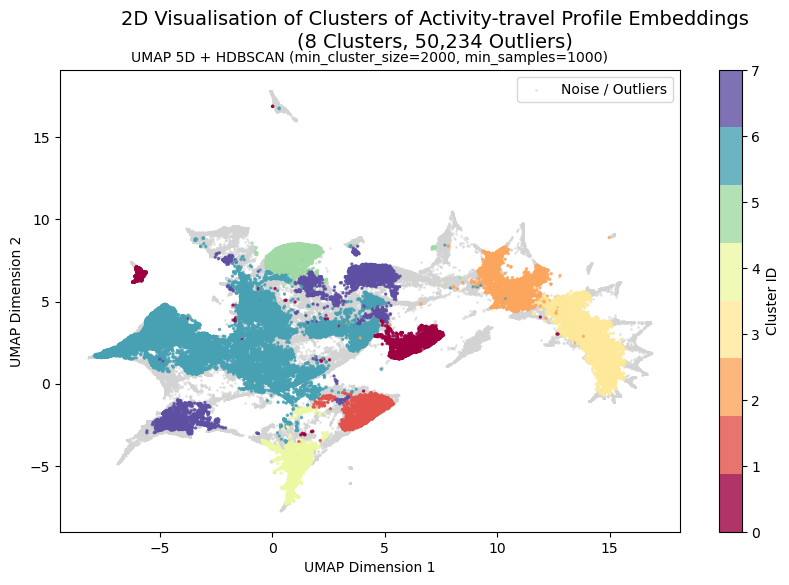

In [36]:
hdbscan_min_cluster_size = 2000
hdbscan_min_samples = 1000

num_clusters = df_user_activity_profile[f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}'].nunique() - 1  # Subtract 1 to exclude noise cluster (-1)
num_outliers = (df_user_activity_profile[f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}'] == -1).sum()

# 5. Plotting the clusters
plt.figure(figsize=(10, 6))

# Plot the outliers (-1) in light gray, pushed to the background
outliers = df_user_activity_profile[df_user_activity_profile[f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}'] == -1]
plt.scatter(outliers['umap_x'], outliers['umap_y'], 
            c='lightgray', s=1, alpha=0.5, label='Noise / Outliers')

# Plot the distinct clusters
clustered = df_user_activity_profile[df_user_activity_profile[f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}'] != -1]

# Get the unique cluster IDs (excluding noise if you already filtered it out)
unique_clusters = np.sort(clustered[f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}'].unique())
num_unique_clusters = len(unique_clusters)

# 1. Create a discrete colormap with exactly the right number of color "blocks"
discrete_cmap = plt.get_cmap('Spectral', num_unique_clusters)

# 2. Pass the discrete_cmap to your scatter plot
scatter = plt.scatter(clustered['umap_x'], clustered['umap_y'], 
                      c=clustered[f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}'], 
                      cmap=discrete_cmap, 
                      s=2, alpha=0.8)

plt.suptitle(f"2D Visualisation of Clusters of Activity-travel Profile Embeddings\n({num_clusters} Clusters, {num_outliers:,} Outliers)", fontsize=14)
plt.title(f"UMAP {umap_config['n_components']}D + HDBSCAN (min_cluster_size={hdbscan_min_cluster_size}, min_samples={hdbscan_min_samples})", fontsize=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label='Cluster ID')
plt.legend()
plt.show()

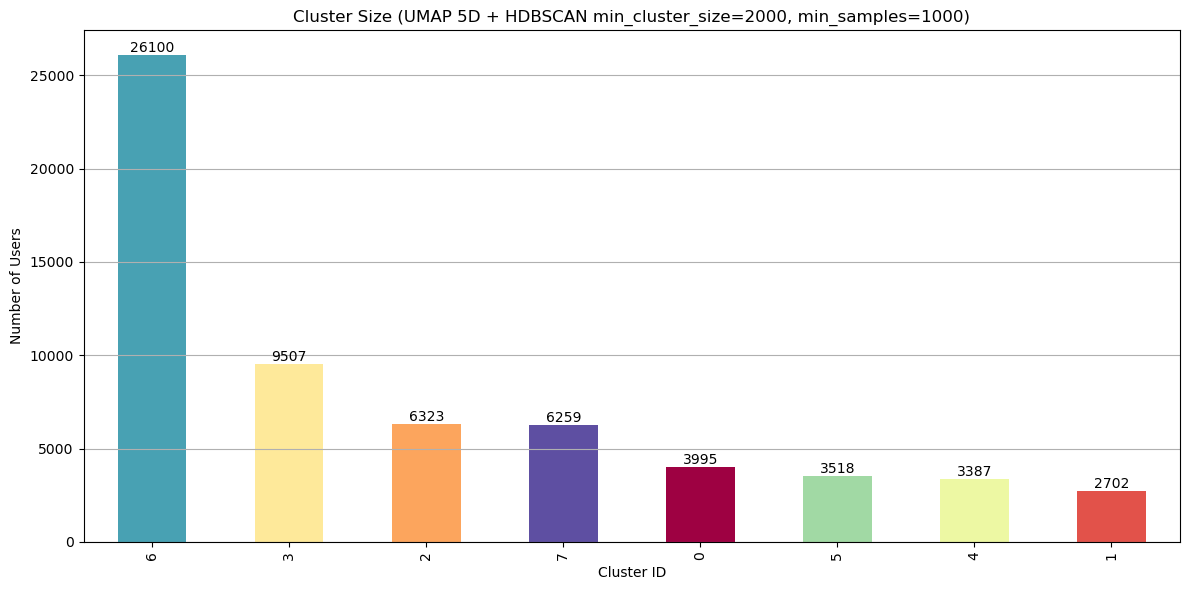

In [37]:
cluster_counts = df_user_activity_profile[f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}'].value_counts()
# Exclude outliers/noise cluster (-1) from the bar chart
cluster_counts = cluster_counts[cluster_counts.index != -1]
cluster_counts

# Plot histogram of cluster sizes with colors matching 2D visualization
plt.figure(figsize=(12, 6))
discrete_cmap = plt.get_cmap('Spectral', num_unique_clusters)
bar_colors = [discrete_cmap(int(cluster_id)) for cluster_id in cluster_counts.index]
cluster_counts.plot(kind='bar', color=bar_colors)
plt.title(f"Cluster Size (UMAP {umap_config['n_components']}D + HDBSCAN min_cluster_size={hdbscan_min_cluster_size}, min_samples={hdbscan_min_samples})")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Users")
plt.grid(axis='y')
# Label the bars with counts
for index, value in enumerate(cluster_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [38]:
df_user_activity_profile

,user_id,activity_profile_embedding,umap_x,umap_y,clst_id_umap5d_size2000_sample2000,clst_id_umap5d_size1000_sample20,clst_id_umap5d_size2000_sample1000
0,000088cc-b646-409b-a026-69cd9d47b838,"[0.007200435540819706, 0.007200413008146831, 0...",4.474168,-1.923559,0,3,1
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,"[0.15784482934966934, 0.011251200931987324, 0....",5.084412,4.951690,-1,9,-1
2,000135bd-bf0b-4880-af99-1791ce98dddf,"[0.05047496908718652, 0.007098476217492361, 0....",1.633864,2.978761,0,15,-1
3,00016f95-edc9-4642-a6e6-70ce63b66346,"[0.017745289312209332, 0.014127804655025446, 0...",11.407210,6.282671,1,14,2
4,0001dfff-15bc-404b-a5f2-a1ec0b458766,"[0.01511074482255483, 0.012252575464614354, 0....",11.709895,6.492467,1,14,2
...,...,...,...,...,...,...,...
112020,fffeb333-944f-4663-aea6-f310fe721d03,"[0.011904851533472538, 0.011904822662472725, 0...",15.428790,6.169834,-1,-1,-1
112021,ffff1696-ce5a-499c-a567-1a9f612ca0c2,"[0.012858757381578661, 0.010258485981923169, 0...",8.383412,1.842725,-1,3,-1
112022,ffff1d0a-e065-451c-ab38-61d881dae01f,"[0.005427960003139604, 0.005427920999463329, 0...",-6.155204,-3.669520,-1,-1,-1
112023,ffff2a7d-c1e9-4364-a074-59fc733599f6,"[0.035714466124773026, 0.03571435436606407, 0....",-0.082984,17.802507,-1,0,-1


In [39]:
# save to local
df_user_activity_profile.to_csv(f"{city}_{str_study_period}_user_activity_profile_with_clusters.csv.gz", index=False)

## 5. Analysis

In [40]:
# Read user clustering results
df_user_activity_profile = pd.read_csv(f"{city}_{str_study_period}_user_activity_profile_with_clusters.csv.gz", compression='gzip')
df_user_activity_profile['activity_profile_embedding'] = df_user_activity_profile['activity_profile_embedding'].apply(ast.literal_eval)
df_user_activity_profile.head()

,user_id,activity_profile_embedding,umap_x,umap_y,clst_id_umap5d_size2000_sample2000,clst_id_umap5d_size1000_sample20,clst_id_umap5d_size2000_sample1000
0,000088cc-b646-409b-a026-69cd9d47b838,"[0.007200435540819706, 0.007200413008146831, 0...",4.474168,-1.923559,0,3,1
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,"[0.15784482934966934, 0.011251200931987324, 0....",5.084412,4.951690,-1,9,-1
2,000135bd-bf0b-4880-af99-1791ce98dddf,"[0.05047496908718652, 0.007098476217492361, 0....",1.633864,2.978761,0,15,-1
3,00016f95-edc9-4642-a6e6-70ce63b66346,"[0.017745289312209332, 0.014127804655025446, 0...",11.407210,6.282671,1,14,2
4,0001dfff-15bc-404b-a5f2-a1ec0b458766,"[0.01511074482255483, 0.012252575464614354, 0....",11.709895,6.492467,1,14,2


In [44]:
df_user_activity_profile.describe()

,umap_x,umap_y,clst_id_umap5d_size2000_sample2000,clst_id_umap5d_size1000_sample20,clst_id_umap5d_size2000_sample1000
count,112025.000000,112025.000000,112025.000000,112025.000000,112025.000000
mean,2.990600,3.174340,-0.037902,6.894916,2.010141
std,6.144323,3.850775,0.620813,8.139674,3.132965
min,-8.194388,-7.729616,-1.000000,-1.000000,-1.000000
25%,-1.353833,1.036338,0.000000,-1.000000,-1.000000
50%,1.545262,3.179706,0.000000,3.000000,1.000000
75%,6.790018,5.848692,0.000000,14.000000,6.000000
max,16.862514,17.831667,1.000000,23.000000,7.000000


### 5.1. Cluster Centroid Distribution

In [45]:
hdbscan_config

{'min_cluster_size': 2000, 'min_samples': 1000}

In [46]:
clst_res_col_name = f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_config["min_cluster_size"]}_sample{hdbscan_config["min_samples"]}'
print(f"The cluster result column name is: {clst_res_col_name}")

# Get cluster centroid embeddings
cluster_centroid_embeddings = df_user_activity_profile.groupby(clst_res_col_name)['activity_profile_embedding'].apply(lambda x: np.mean(x.tolist(), axis=0)).reset_index()

# Make the cluster id start from 1 instead of 0, and keep -1 for outliers.
cluster_centroid_embeddings[clst_res_col_name] = cluster_centroid_embeddings[clst_res_col_name].apply(lambda x: x + 1 if x != -1 else -1)

cluster_centroid_embeddings = cluster_centroid_embeddings[cluster_centroid_embeddings[clst_res_col_name] != -1].reset_index(drop=True)
cluster_centroid_embeddings

The cluster result column name is: clst_id_umap5d_size2000_sample1000


,clst_id_umap5d_size2000_sample1000,activity_profile_embedding
0,1,"[0.017056397672450832, 0.011842240424404828, 0..."
1,2,"[0.01381691050539694, 0.01224030210443833, 0.0..."
2,3,"[0.018808880746048653, 0.014982796023274373, 0..."
3,4,"[0.010651424798373397, 0.009341868967738517, 0..."
4,5,"[0.01975934632243511, 0.015536496817355262, 0...."
5,6,"[0.014409007335637084, 0.012046543609319496, 0..."
6,7,"[0.23930092403830142, 0.020995027795984635, 0...."
7,8,"[0.015742804188328845, 0.015332881900249107, 0..."


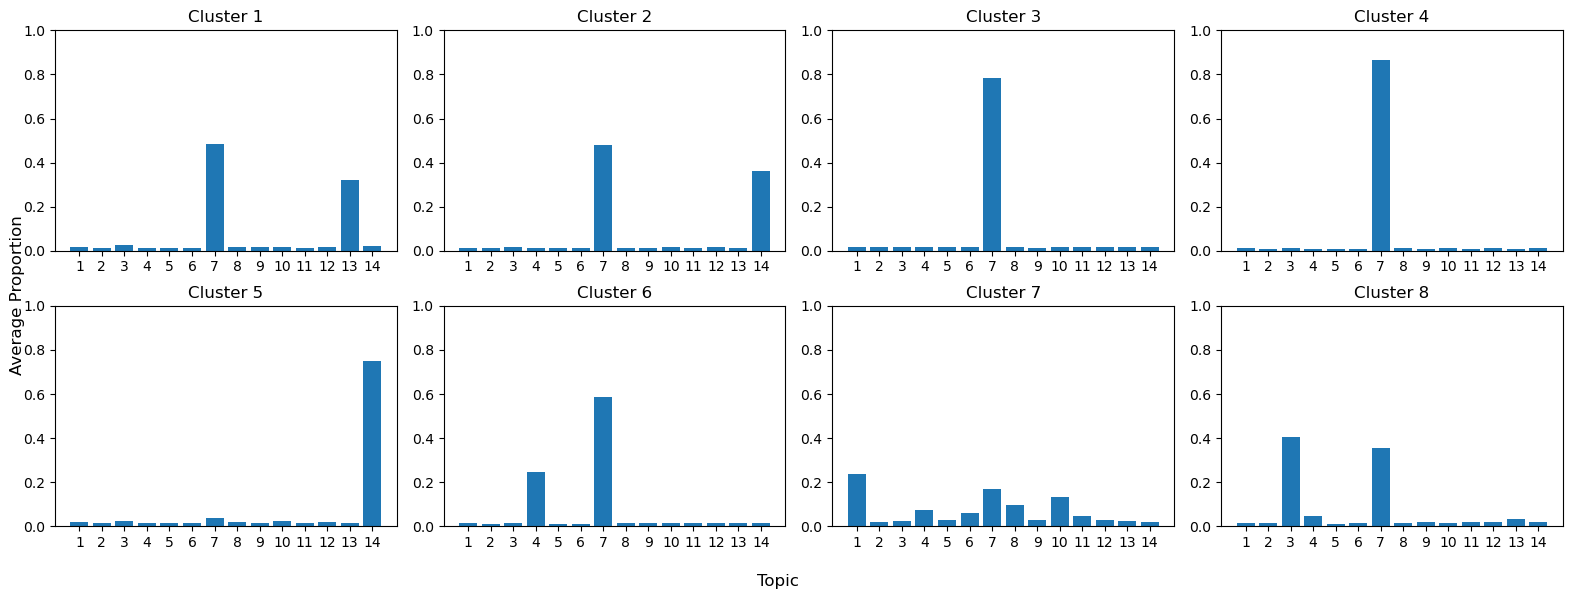

In [62]:
# Visualise the cluster centroids in subplots (excluding noise cluster), each subplot is a bar chart of the average topic distribution for that cluster
cluster_col = f'clst_id_umap{umap_config["n_components"]}d_size{hdbscan_min_cluster_size}_sample{hdbscan_min_samples}'
num_clusters_to_plot = len(cluster_centroid_embeddings)
num_cols = 4
num_rows = (num_clusters_to_plot + num_cols - 1) // num_cols

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(num_cols * 4, num_rows * 3),
    sharex=False,
    sharey=False,
)
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, cluster_centroid_embeddings.iterrows()):
    topic_values = row['activity_profile_embedding']
    topic_ids = [i + 1 for i in range(len(topic_values))]
    ax.bar(topic_ids, topic_values)
    ax.set_title(f"Cluster {row[cluster_col]}")
    ax.set_xticks(list(topic_ids))
    ax.set_ylim(0, 1)

for ax in axes[num_clusters_to_plot:]:
    ax.set_visible(False)

fig.supxlabel("Topic")
fig.supylabel("Average Proportion")
fig.tight_layout()
fig.subplots_adjust(hspace=0.25)

# save figure
plt.savefig(f"{city}_{str_study_period}_cluster_centroid_topic_distributions.png", dpi=400, bbox_inches='tight')
plt.show()
